In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import tree
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3, random_state= 42)

clf= DecisionTreeClassifier()
clf.fit(X_train, y_train)


DecisionTreeClassifier()

In [34]:
pd.Series(y).unique()
df = pd.DataFrame(X, columns= data.feature_names)

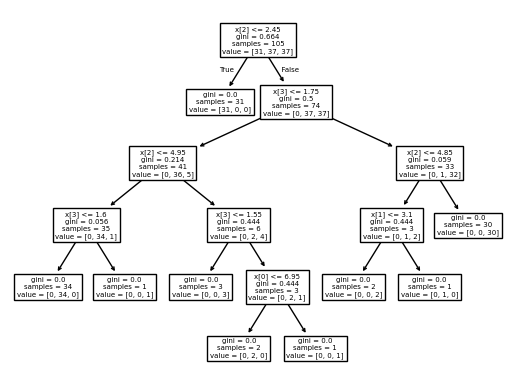

In [9]:
tree.plot_tree(clf)
plt.show()

In [ ]:
n_nodes = clf.tree_.node_count ##No of nodes
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
feature = clf.tree_.feature
threshold = clf.tree_.threshold
values = clf.tree_.value  # show each node with raw class counts at every node in the tree.

array([ 2.44999999, -2.        ,  1.75      ,  4.95000005,  1.60000002,
       -2.        , -2.        ,  1.55000001, -2.        ,  6.94999981,
       -2.        , -2.        ,  4.85000014,  3.10000002, -2.        ,
       -2.        , -2.        ])

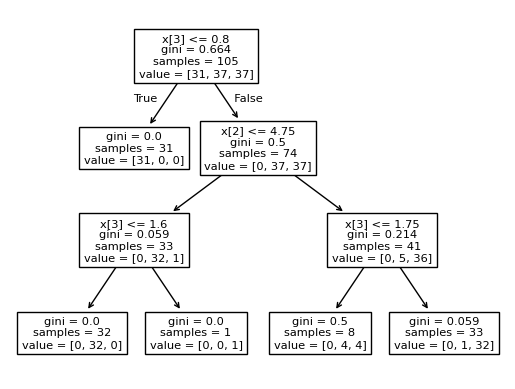

In [48]:
clf_2 = DecisionTreeClassifier(max_depth=3)
clf_2.fit(X_train, y_train)
tree.plot_tree(clf_2)
plt.show()

In [ ]:
# min_samples_split → guards the PARENT
DecisionTreeClassifier(min_samples_split=20)
# Node with 6 samples? → skip splitting, make it a leaf directly

# min_samples_leaf → guards the CHILDREN
DecisionTreeClassifier(min_samples_leaf=10)
# A split that produces a child with 1 sample? → reject that split entirely
# The tree will search for a different split threshold that keeps both children >= 10

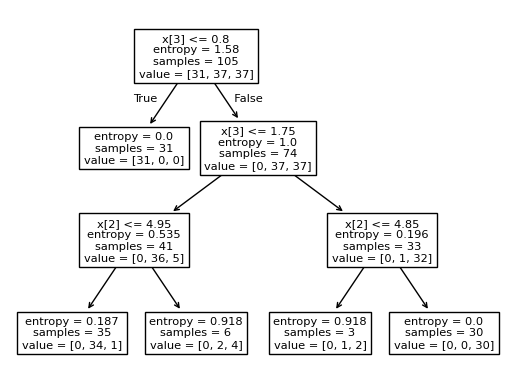

In [47]:
clf_3 = DecisionTreeClassifier(criterion= 'entropy', max_depth= 3)
clf_3.fit(X_train, y_train)
tree.plot_tree(clf_3)
plt.show()

In [49]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

# ID3 — entropy, no pruning
id3 = DecisionTreeClassifier(criterion='entropy')

# C4.5 — entropy + light pruning
c45 = DecisionTreeClassifier(criterion='entropy', ccp_alpha=0.01)

# C5.0 — entropy + stronger pruning
c50 = DecisionTreeClassifier(criterion='entropy', ccp_alpha=0.02)

# CART — gini (sklearn's actual native algorithm)
cart = DecisionTreeClassifier(criterion='gini')

for name, clf in [('ID3', id3), ('C4.5', c45), ('C5.0', c50), ('CART', cart)]:
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f'{name}: nodes={clf.tree_.node_count}, depth={clf.get_depth()}, acc={acc:.4f}')

ID3: nodes=17, depth=5, acc=1.0000
C4.5: nodes=19, depth=7, acc=0.9778
C5.0: nodes=13, depth=5, acc=0.9778
CART: nodes=19, depth=6, acc=1.0000
